# Seaborn 04 - Seaborn Solutions

> **MLCourse · Data Science Foundations · 04_seaborn**

Fully worked, standalone solutions to the twelve challenges in
`03_seaborn_exercises`. Every cell is self-contained commentary + code: read
the reasoning, run it, then go back and re-solve each exercise WITHOUT
looking - that second pass is where it becomes yours.

Where multiple valid designs exist (they usually do), we note the trade-off
inline. Plotting is judgment, not incantation.

### What you'll learn

- Reference implementations of all twelve challenges with the *why* behind
  every parameter choice.
- Defensive dataset loading (with synthetic fallbacks) so this file runs
  even fully offline.
- Patterns worth stealing: ordering from groupby, percentile bands via
  `map_dataframe`, dashboard composition on shared matplotlib figures.

### Setup & defensive data loading

The loader tries seaborn's online registry first; if that fails we fall
back to small synthetic DataFrames with identical columns so every solution
below still executes end-to-end.

In [1]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
except NameError:
    pass

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme()


def load_dataset(name):
    """Load a built-in seaborn dataset; return None if unavailable."""
    try:
        return sns.load_dataset(name)
    except Exception as exc:
        print(f"[offline hint] '{name}' unavailable ({exc}); using synthetic fallback.")
        return None


def _fallback(name, n=240):
    """Small synthetic stand-ins with the columns our solutions rely on."""
    rng = np.random.default_rng(42)
    days = rng.choice(["Thur", "Fri", "Sat", "Sun"], n)
    times = rng.choice(["Lunch", "Dinner"], n, p=[0.35, 0.65])
    smokers = rng.choice(["Yes", "No"], n, p=[0.4, 0.6])
    sexes = rng.choice(["Male", "Female"], n, p=[0.65, 0.35])
    bill = rng.gamma(2.2, 9.5, n) + 3
    tip = bill * rng.uniform(0.08, 0.20, n)
    species = rng.choice(["Adelie", "Chinstrap", "Gentoo"], n)
    if name == "tips":
        return pd.DataFrame({"total_bill": bill.round(2), "tip": tip.round(2),
                             "day": days, "time": times, "smoker": smokers,
                             "sex": sexes})
    if name == "penguins":
        base = {"Adelie": [38.8, 18.3, 190, 3700], "Chinstrap": [48.8, 18.4, 195, 3730],
                "Gentoo": [47.5, 15.0, 217, 5070]}[species[0]]
        rows = []
        for s in species:
            m = {"Adelie": [38.8, 18.3, 190, 3700], "Chinstrap": [48.8, 18.4, 195, 3730],
                 "Gentoo": [47.5, 15.0, 217, 5070]}[s]
            vals = np.array(m) + rng.normal(0, [2.5, 1.0, 7, 300])
            rows.append([s, *vals])
        return pd.DataFrame(rows, columns=["species", "bill_length_mm",
                                           "bill_depth_mm", "flipper_length_mm",
                                           "body_mass_g"])
    if name == "mpg":
        origin = rng.choice(["usa", "japan", "europe"], n, p=[0.62, 0.20, 0.18])
        hp = rng.uniform(50, 230, n)
        return pd.DataFrame({"horsepower": hp,
                             "mpg": 48 - 0.12 * hp + rng.normal(0, 4, n),
                             "weight": rng.uniform(1600, 5000, n),
                             "acceleration": rng.uniform(8, 24, n),
                             "displacement": rng.uniform(70, 455, n),
                             "origin": origin})
    if name == "titanic":
        cls = rng.choice(["First", "Second", "Third"], n, p=[0.25, 0.21, 0.54])
        return pd.DataFrame({"class": cls,
                             "sex": rng.choice(["male", "female"], n),
                             "alive": rng.choice(["yes", "no"], n, p=[0.38, 0.62])})
    return None


def get(name):
    """Dataset-or-synthetic accessor used throughout."""
    df = load_dataset(name)
    return df if df is not None else _fallback(name)


tips = get("tips")
penguins = get("penguins")
mpg = get("mpg")
titanic = get("titanic")

_diamonds_raw = load_dataset("diamonds")


def dia(n=5000):
    """Reproducible diamonds sample; synthetic carat/price if offline."""
    if _diamonds_raw is not None:
        return _diamonds_raw.sample(n, random_state=42)
    rng = np.random.default_rng(42)
    cuts = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
    return pd.DataFrame({
        "carat": rng.gamma(1.6, 0.35, n).clip(0.2, 4.5),
        "price": rng.lognormal(7.7, 0.55, n).round(0),
        "cut": rng.choice(cuts, n, p=[0.13, 0.19, 0.22, 0.26, 0.20]),
    })


print("ready:", {k: v.shape for k, v in
                 [("tips", tips), ("penguins", penguins),
                  ("mpg", mpg), ("titanic", titanic)]})

ready: {'tips': (244, 7), 'penguins': (344, 7), 'mpg': (398, 9), 'titanic': (891, 15)}


--------------------------------------------------------------------------

### Challenge 1 - Mean spend by day *(Easy)*

Key moves: derive `order` from the data itself (groupby-mean, sorted) rather
than typing guesses; keep the default bootstrap CI; say what the bars' error
bars are in the title; despine for a clean finish.

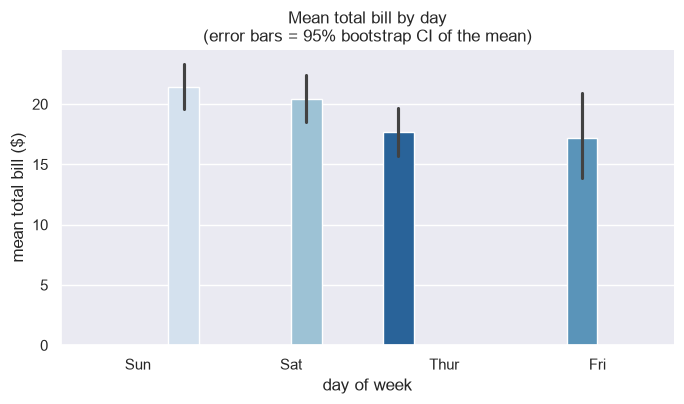

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.2))
day_order = (
    tips.groupby("day")["total_bill"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)
sns.barplot(data=tips, x="day", y="total_bill",
            order=day_order, hue="day", legend=False,
            palette="Blues_r", errorbar=("ci", 95), ax=ax)

ax.set_title("Mean total bill by day\n(error bars = 95% bootstrap CI of the mean)")
ax.set_xlabel("day of week")
ax.set_ylabel("mean total bill ($)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Trade-off note: a pointplot would show the same estimate with less ink and
# no zero-baseline debate - try swapping kind as an experiment.

--------------------------------------------------------------------------

### Challenge 2 - ECDF with threshold read-off *(Easy)*

ECDF superpower: at x=4000 g, each curve's height IS the answer. We layer a
rug for raw-data texture, mark the threshold, then verify numerically.

species
Adelie       0.737
Chinstrap    0.765
Gentoo       0.008
Name: under, dtype: float64


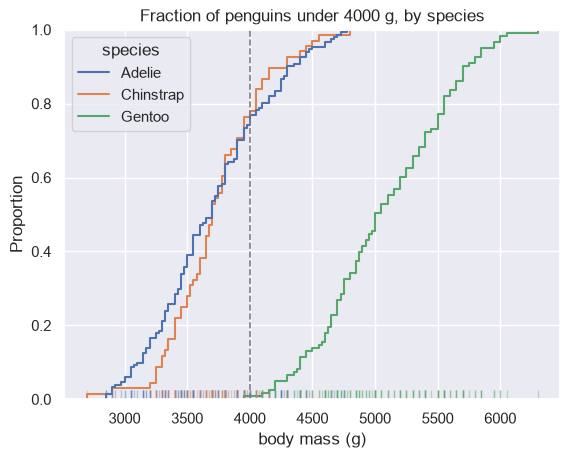

In [3]:
ax = sns.ecdfplot(data=penguins, x="body_mass_g", hue="species")
sns.rugplot(data=penguins, x="body_mass_g", hue="species", ax=ax, alpha=0.35)
ax.axvline(4000, color="gray", ls="--", lw=1.2)
ax.set_title("Fraction of penguins under 4000 g, by species")
ax.set_xlabel("body mass (g)")

frac_under = penguins.assign(under=lambda d: d["body_mass_g"] < 4000)
print(frac_under.groupby("species")["under"].mean().round(3))
plt.show()

# Reading check: Gentoo's curve sits lowest at x=4000 -> fewest light birds;
# Adelie highest -> most. The printed table must agree with your eyeballs.

--------------------------------------------------------------------------

### Challenge 3 - Corner pairplot by origin *(Easy)*

Five variables means twenty bivariate panels when mirrored; `corner=True`
halves it. KDE diagonals beat histograms here because origins overlap heavily.

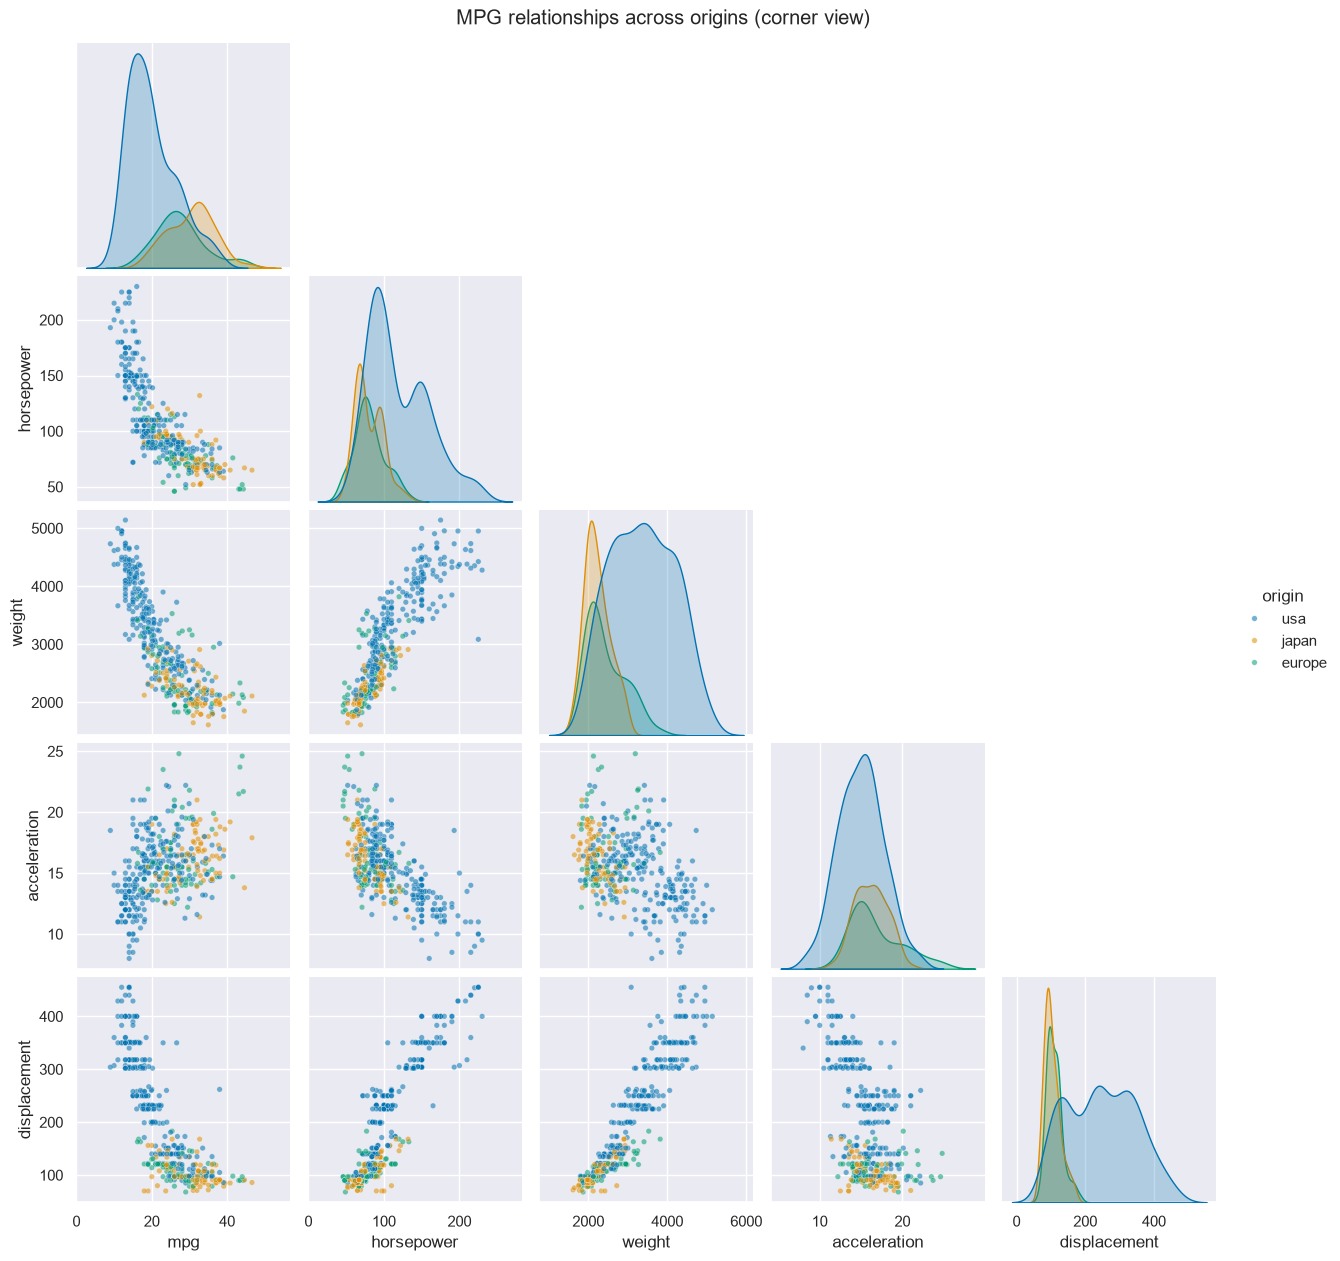

In [4]:
vars_5 = ["mpg", "horsepower", "weight", "acceleration", "displacement"]
pp = sns.pairplot(
    mpg.dropna(subset=vars_5 + ["origin"]),
    vars=vars_5, hue="origin",
    diag_kind="kde", corner=True,
    palette="colorblind",
    plot_kws={"s": 16, "alpha": 0.55},
)
pp.figure.suptitle("MPG relationships across origins (corner view)", y=1.01)
plt.show()

# What to notice: weight-horsepower panel is nearly one line (redundant info);
# acceleration separates origins least - good candidate to drop from models.

--------------------------------------------------------------------------

### Challenge 4 - Colorblind redesign *(Easy)*

~8% of men have color-vision deficiency; default palettes can pair red/green
hues that collapse into one for them. Preview candidates first, then apply
per-call (safest - nothing leaks) and demo the global route too.

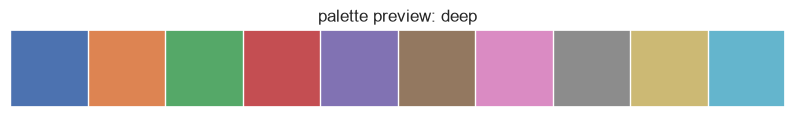

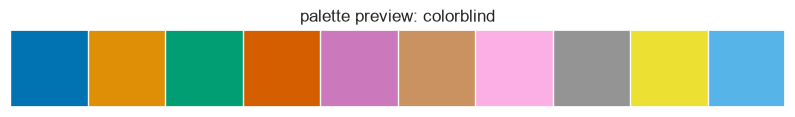

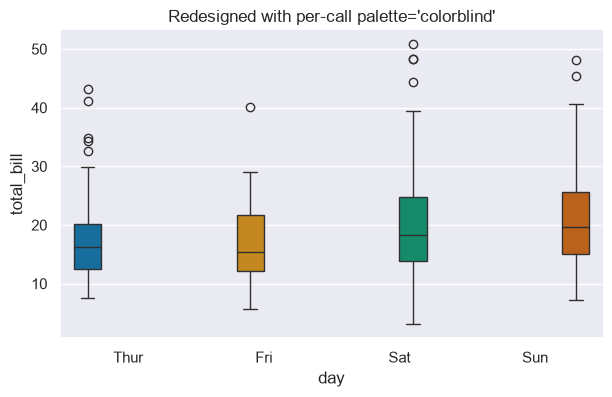

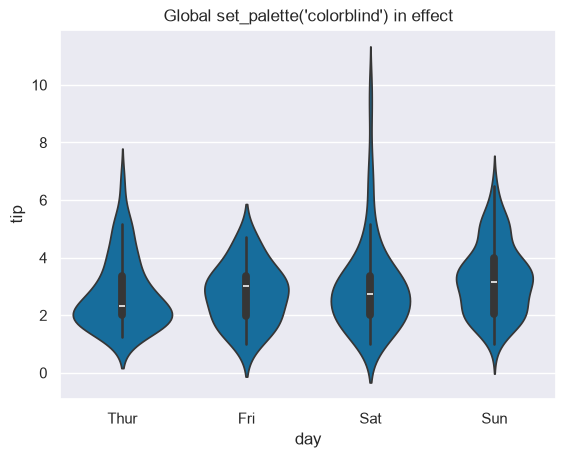

palette restored to 'deep'


In [5]:
for name in ["deep", "colorblind"]:
    sns.palplot(sns.color_palette(name))
    plt.title(f"palette preview: {name}")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=tips, x="day", y="total_bill", hue="day", legend=False,
            palette="colorblind", ax=ax)
ax.set_title("Redesigned with per-call palette='colorblind'")
sns.despine(ax=ax)
plt.show()

sns.set_palette("colorblind")     # global route: affects ALL later plots...
ax = sns.violinplot(data=tips, x="day", y="tip")
ax.set_title("Global set_palette('colorblind') in effect")
plt.show()

sns.set_palette("deep")           # ...so restore the default afterwards.
print("palette restored to 'deep'")

--------------------------------------------------------------------------

### Challenge 5 - Faceted regression per origin *(Medium)*

`lmplot` fits independently per facet - exactly the question "same slope
everywhere?". We check facet sizes FIRST because regression on a handful of
European cars from 1970s data would be theater, not statistics.

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


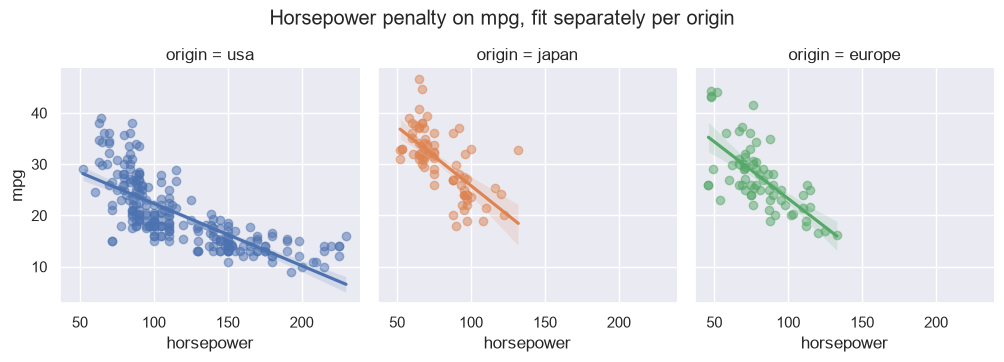

In [6]:
print(mpg["origin"].value_counts())

g = sns.lmplot(
    data=mpg, x="horsepower", y="mpg",
    col="origin", hue="origin",
    height=3.4, scatter_kws={"alpha": 0.5},
)
g.set_axis_labels("horsepower", "mpg")
g.figure.suptitle("Horsepower penalty on mpg, fit separately per origin", y=1.06)
plt.show()

# Observation: slopes look similar-ish but intercepts differ - europe/japan
# sit higher (efficient) at equal power. USA's steeper line reflects its
# big-engine tail stretching the fit.

--------------------------------------------------------------------------

### Challenge 6 - One variable, three lenses *(Medium)*

Box = robust five-number summary; violin = full shape (watch for smoothing
artifacts); ECDF = thresholds and medians without any tuning. Same data, three
honest views - disagreement between them is itself informative.

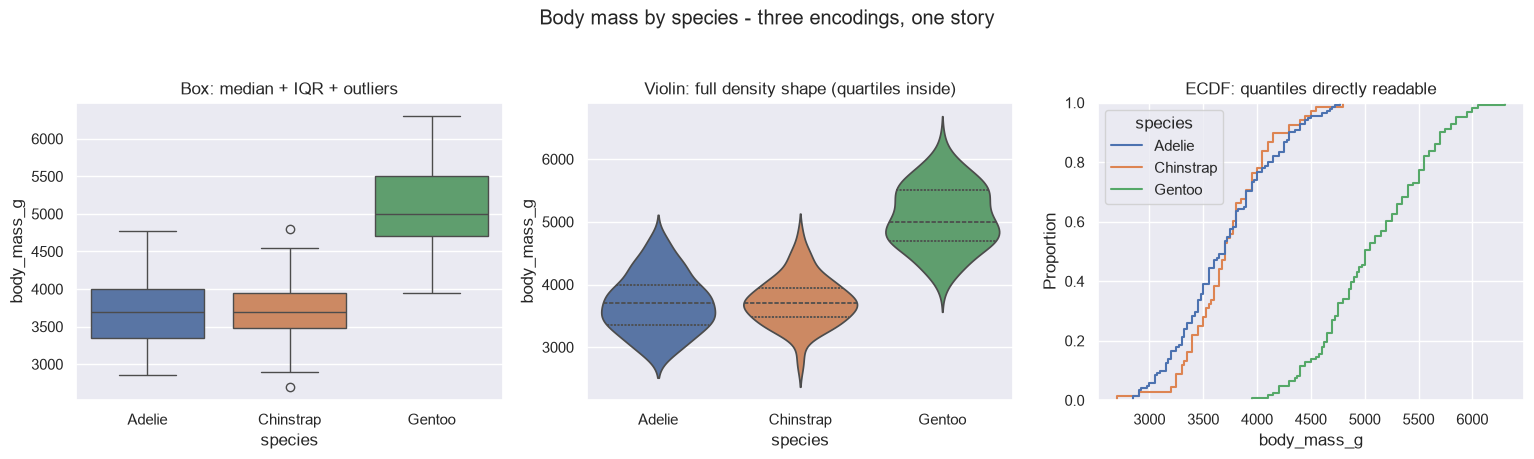

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

sns.boxplot(data=penguins, x="species", y="body_mass_g",
            hue="species", legend=False, ax=axes[0])
axes[0].set_title("Box: median + IQR + outliers")

sns.violinplot(data=penguins, x="species", y="body_mass_g",
               hue="species", legend=False, inner="quart", ax=axes[1])
axes[1].set_title("Violin: full density shape (quartiles inside)")

sns.ecdfplot(data=penguins, x="body_mass_g", hue="species", ax=axes[2])
axes[2].set_title("ECDF: quantiles directly readable")

fig.suptitle("Body mass by species - three encodings, one story", y=1.04)
plt.tight_layout()
plt.show()

# All three agree: Gentoo shifted high (~5 kg), Adelie/Chinstrap overlapping.
# If they HAD disagreed you'd suspect binning/bandwidth choices, not biology.

--------------------------------------------------------------------------

### Challenge 7 - Masked correlation heatmap *(Medium)*

Correlation matrices are symmetric with a trivial diagonal - showing all of
it doubles reading cost for zero information. Mask above-diagonal, pin the
diverging scale to [-1, 1] centered at 0, and extract top pairs in code.

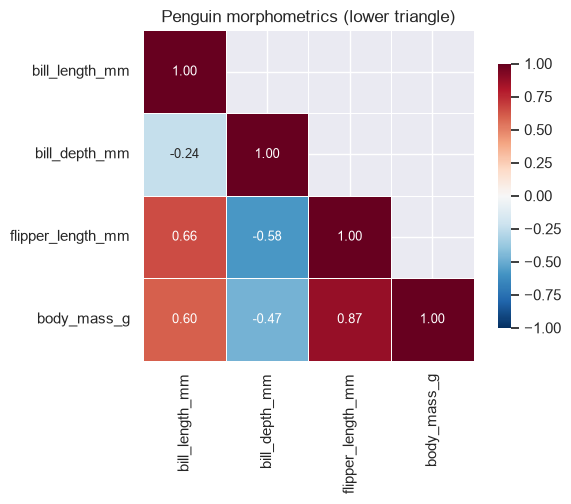

          level_0           level_1        r
flipper_length_mm       body_mass_g 0.871202
   bill_length_mm flipper_length_mm 0.656181
   bill_length_mm       body_mass_g 0.595110


In [8]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins[num_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # k=1 keeps the diagonal

fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f", annot_kws={"fontsize": 9},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Penguin morphometrics (lower triangle)")
plt.tight_layout()
plt.show()

top_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack().rename("r").reset_index()
        .sort_values("r", key=np.abs, ascending=False)
)
print(top_pairs.head(3).to_string(index=False))

# flipper-mass (~+0.87) dominates; bill depth flips sign against length -
# largely a Gentoo effect. Group-wise heatmaps are a great follow-up.

--------------------------------------------------------------------------

### Challenge 8 - Hexbin jointplot on big data *(Medium)*

At thousands of points, scatters overdraw: dark where data is dense is
indistinguishable from dark where two points coincide. Hexbin counts falls
into bins - honest density, cheap to render. Marginals remind us BOTH
variables skew right.

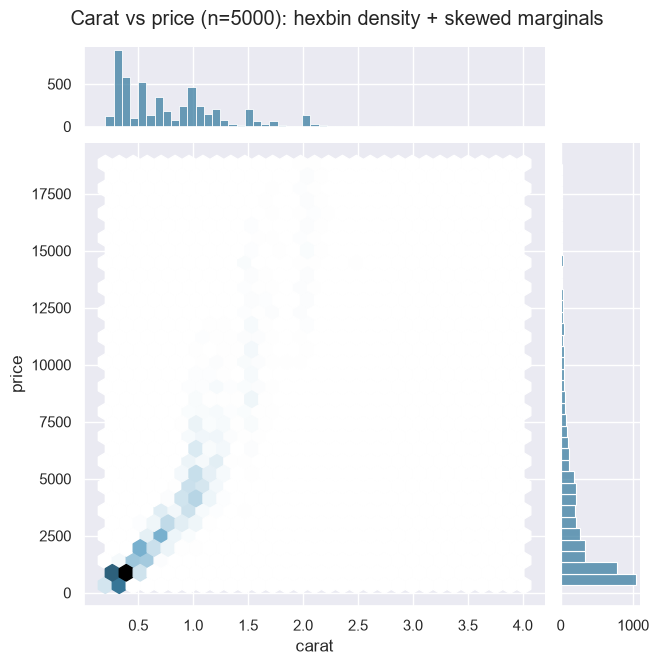

In [9]:
d5k = dia()
j = sns.jointplot(
    data=d5k, x="carat", y="price",
    kind="hex", height=6.5, marginal_ticks=True,
    joint_kws={"gridsize": 30},
    color="#3b7ea1",
)
j.figure.suptitle("Carat vs price (n=5000): hexbin density + skewed marginals",
                  y=1.02)
plt.show()

# gridsize=30 balances resolution vs noise; try 15 and 60 to feel the trade.

--------------------------------------------------------------------------

### Challenge 9 - Pivot heatmap with centered midpoint *(Medium)*

Diverging colors only make sense around a MEANINGFUL center. We center at
the overall median tip: cells near typical tipping stay neutral, expensive
tips glow warm, stingy ones cool. Days re-indexed Thu→Sun for calendar sense.

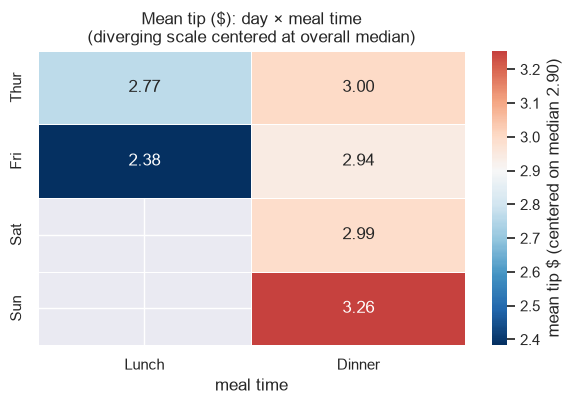

In [10]:
day_order_cal = ["Thur", "Fri", "Sat", "Sun"]
pivot = tips.pivot_table(index="day", columns="time", values="tip",
                         aggfunc="mean", observed=False).reindex(day_order_cal)
center_val = float(np.median(tips["tip"]))

fig, ax = plt.subplots(figsize=(6, 4.2))
sns.heatmap(
    pivot, annot=True, fmt=".2f",
    cmap="RdBu_r", center=center_val,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": f"mean tip $ (centered on median {center_val:.2f})"},
    ax=ax,
)
ax.set_title("Mean tip ($): day × meal time\n(diverging scale centered at overall median)")
ax.set_xlabel("meal time")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Friday lunches dip cool; Sunday dinners glow warm - the center makes both
# directions readable at once instead of everything shouting 'orange'.

--------------------------------------------------------------------------

### Challenge 10 - FacetGrid percentile bands *(Hard)*

The pattern to internalize: custom functions receive each facet's SUBSET via
`map_dataframe` and draw on `plt.gca()`. Nothing hardcoded - quantiles come
from whatever data lands in the function.

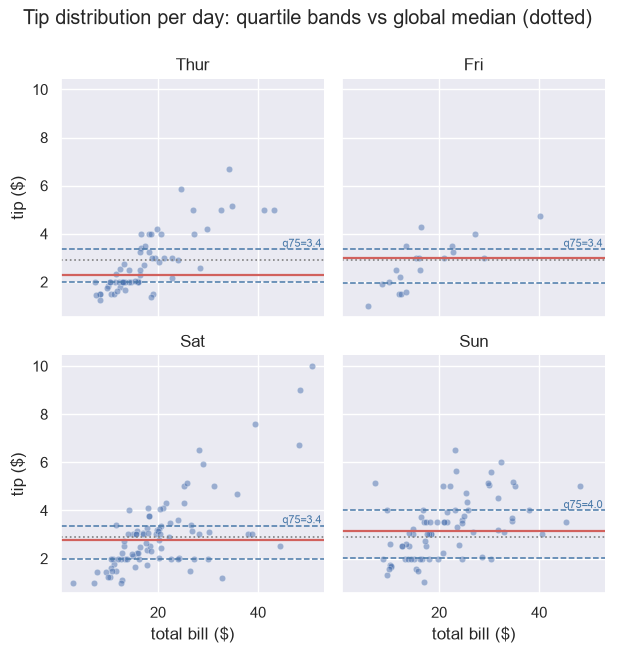

In [11]:
def draw_tip_bands(data, **kws):
    """Per-facet q25 / median / q75 lines for tip (no globals, no hardcoding)."""
    ax = plt.gca()
    q25, q50, q75 = data["tip"].quantile([0.25, 0.50, 0.75])
    ax.axhline(q25, ls="--", lw=1.1, color="#4878a8")
    ax.axhline(q75, ls="--", lw=1.1, color="#4878a8")
    ax.axhline(q50, ls="-", lw=1.6, color="#d1615d")
    ax.text(0.99, q75, f"q75={q75:.1f}", ha="right", va="bottom",
            fontsize=8, color="#4878a8", transform=ax.get_yaxis_transform())


g = sns.FacetGrid(tips, col="day", col_wrap=2, height=3.1)
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip",
                alpha=0.5, s=22)
g.map_dataframe(draw_tip_bands)
g.refline(y=tips["tip"].median(), color="gray", ls=":", lw=1.2)  # global median
g.set_axis_labels("total bill ($)", "tip ($)")
g.set_titles(col_template="{col_name}")
g.add_legend()
g.figure.suptitle("Tip distribution per day: quartile bands vs global median (dotted)",
                  y=1.05)
plt.show()

# Weekend facets lift their whole band ABOVE the dotted global median -
# visible immediately because the reference is drawn identically everywhere.

--------------------------------------------------------------------------

### Challenge 11 - Box vs boxen showdown *(Hard)*

Same variable, same order, same y-scale - the only difference is encoding,
which isolates WHAT boxen adds: nested letter-value boxes exposing tail
structure a single IQR box compresses away.

cut
Fair          162
Good          465
Very Good    1108
Premium      1312
Ideal        1953


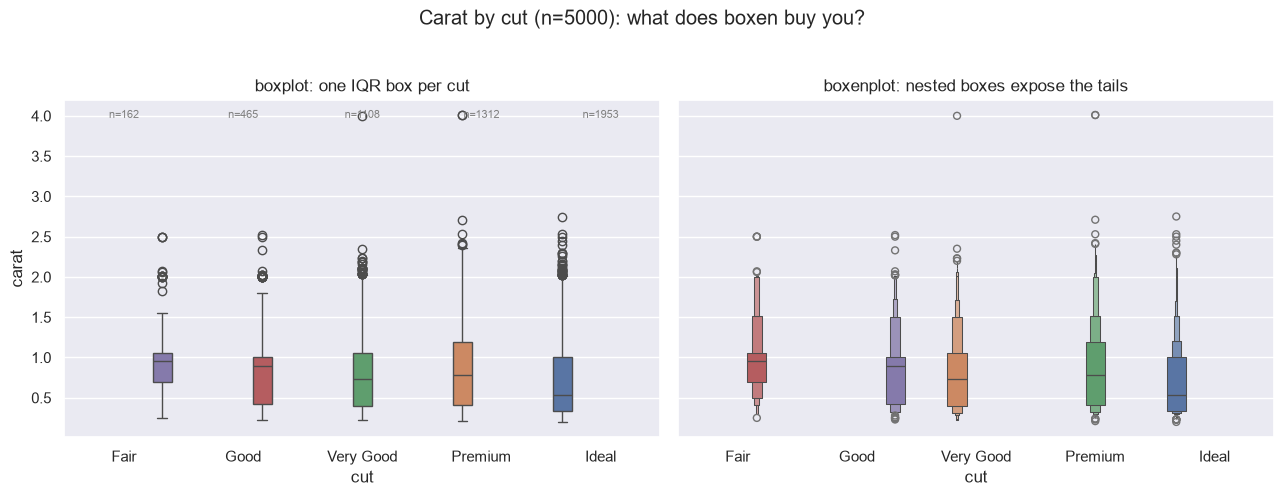

In [12]:
d5k = dia()
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
n_per_cut = d5k["cut"].value_counts().reindex(cut_order)
print(n_per_cut.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
sns.boxplot(data=d5k, x="cut", y="carat", hue="cut", legend=False,
            order=cut_order, ax=axes[0])
axes[0].set_title("boxplot: one IQR box per cut")
sns.boxenplot(data=d5k, x="cut", y="carat", hue="cut", legend=False,
              order=cut_order, ax=axes[1])
axes[1].set_title("boxenplot: nested boxes expose the tails")

# Annotate sample sizes above the left panel's tick labels.
ymax = axes[0].get_ylim()[1]
for i, (cut_name, n) in enumerate(n_per_cut.items()):
    axes[0].text(i, ymax * 0.97, f"n={n}", ha="center", va="top",
                 fontsize=8, color="gray")

fig.suptitle("Carat by cut (n=5000): what does boxen buy you?", y=1.03)
plt.tight_layout()
plt.show()

# Takeaway: better cuts concentrate at SMALLER stones, but Ideal/Premium grow
# long upper tails - boxen shows those sub-populations; the plain box only
# hints via fliers. With tiny n (<100/group), boxen's extra boxes would be
# noise: prefer the plain box there.

--------------------------------------------------------------------------

### Challenge 12 - Mini-dashboard *(Hard)*

Four questions, four encodings, ONE figure: distribution (violin), matrix
(pivot heatmap), interaction (pointplot), cumulative comparison (ECDF).
Everything axes-level so it slots into the shared subplot grid.

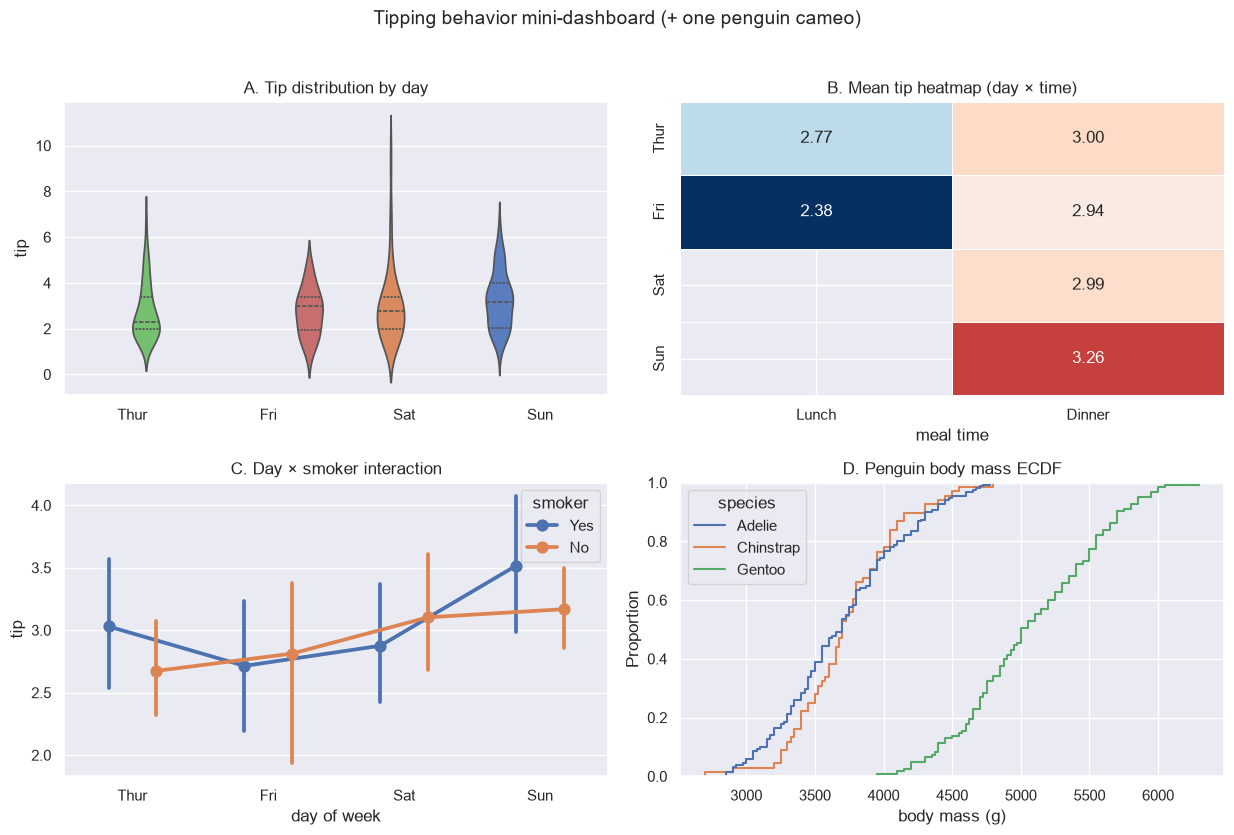

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))

# Panel A - distribution: violin beats bar charts for shape questions.
sns.violinplot(data=tips, x="day", y="tip", hue="day", legend=False,
               inner="quart", palette="muted", ax=axes[0, 0])
axes[0, 0].set_title("A. Tip distribution by day")
axes[0, 0].set_xlabel("")

# Panel B - matrix: reuse the Challenge-9 pivot; drop the colorbar for space.
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r",
            center=center_val, linewidths=0.5, cbar=False, ax=axes[0, 1])
axes[0, 1].set_title("B. Mean tip heatmap (day × time)")
axes[0, 1].set_xlabel("meal time")
axes[0, 1].set_ylabel("")

# Panel C - interaction: non-parallel lines = smoker effect varies by day.
sns.pointplot(data=tips, x="day", y="tip", hue="smoker",
              dodge=0.35, errorbar=("ci", 95), ax=axes[1, 0])
axes[1, 0].set_title("C. Day × smoker interaction")
axes[1, 0].set_xlabel("day of week")

# Panel D - cumulative: mixing datasets is fine when panels are clearly titled.
sns.ecdfplot(data=penguins, x="body_mass_g", hue="species", ax=axes[1, 1])
axes[1, 1].set_title("D. Penguin body mass ECDF")
axes[1, 1].set_xlabel("body mass (g)")

fig.suptitle("Tipping behavior mini-dashboard (+ one penguin cameo)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Design notes: colorbar sacrificed for grid real estate (values annotated);
# every panel self-titled so the dashboard survives being cropped apart;
# legends kept only where hue carries meaning.

### Summary & key takeaways

- **Order from data** (`groupby(...).mean().sort_values()` → `order=`) -
  never hand-typed category orders.
- **Say what uncertainty is**: CI-of-mean vs SD-of-data changes interpretation;
  titles/captions should carry that label.
- **Mask symmetric matrices**, center diverging scales on meaningful values,
  and extract top pairs programmatically.
- **Sample large tables reproducibly** (`random_state=42`) before heavy plots.
- **Custom `FacetGrid` functions** unlock per-facet statistics (quartile
  bands, means) while `refline` anchors them against a global benchmark.
- **Dashboards** = axes-level functions + `plt.subplots` + disciplined
  titles; figure-level convenience ends where composition begins.

You now hold the complete seaborn toolkit from this module: foundations,
advanced grids, and twelve reps of applied judgment. Onward to the next
visualization library chapter!